In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
    .appName("ethereum_ingestion_EDA")\
    .master("local[*]")\
    .config("spark.driver.memory", "6g")\
    .config("spark.executor.memory", "10g")\
    .config("spark.sql.adaptive.enabled", "true")\
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")\
    .config("spark.sql.autoBroadcastJoinThreshold", "100mb")\
    .config("spark.sql.parquet.filterPushdown", "true")\
    .config("spark.driver.maxResultSize", "4g")\
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/21 22:58:01 WARN Utils: Your hostname, khanhdo-VMware-Virtual-Platform, resolves to a loopback address: 127.0.1.1; using 192.168.118.128 instead (on interface ens33)
26/04/21 22:58:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
E0000 00:00:1776787083.258874    5535 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1776787083.258936    5535 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1776787083.258939    5535 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped'

In [8]:
import pyspark.sql.functions as F

## Xử lý file tokens:
Bỏ trùng address + bỏ token decimal > 18

In [3]:
# tokens.parquet
df_tokens = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/tokens.parquet")
df_tokens.printSchema()
df_tokens.show(5)
df_tokens.count()

root
 |-- address: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- name: string (nullable = true)
 |-- decimals: string (nullable = true)
 |-- total_supply: string (nullable = true)

+--------------------+------+-----+--------+--------------------+
|             address|symbol| name|decimals|        total_supply|
+--------------------+------+-----+--------+--------------------+
|0x4bfbff63d03d93a...|      |     |      18|10000000000000000...|
|0x3498eaf5ec296eb...|    NM|NenMo|       4|        880000000000|
|0x9d1a236f1de06ab...| SPEED|Speed|      18|24229371788186338...|
|0x15ff21740d9e52a...|  WARP| Warp|      18|22443493719574827...|
|0xd32e32780734440...|      |     |      18|10000000000000000...|
+--------------------+------+-----+--------+--------------------+
only showing top 5 rows


174014

In [4]:
# Dedup + lọc decimals null
df_tokens = df_tokens.dropDuplicates(["address"]).filter(F.col("decimals").isNotNull())

df_tokens.printSchema()
df_tokens.show(5)
df_tokens.count()

root
 |-- address: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- name: string (nullable = true)
 |-- decimals: string (nullable = true)
 |-- total_supply: string (nullable = true)



+--------------------+------+--------------------+--------+--------------------+
|             address|symbol|                name|decimals|        total_supply|
+--------------------+------+--------------------+--------+--------------------+
|0x0000000000b3f87...|  GST2|         Gastoken.io|       2|             1361386|
|0x000000630a383f8...|  weth|Wrapped Ether (Ga...|      18|43290037992203770...|
|0x000000d2870857f...|  weth|Wrapped Ether (Ga...|      18|43290037992203770...|
|0x0000b6ab44789eb...|   VSN|      Vision Network|      18|           250000000|
|0x00016fab0fa144c...|  last|lite adaptable sy...|       1|           420000000|
+--------------------+------+--------------------+--------+--------------------+
only showing top 5 rows


174008

In [5]:

df_tokens_processed = df_tokens.filter(F.col("decimals") <= 18)
df_tokens_processed.distinct().show()

+--------------------+-------+--------------------+--------+--------------------+
|             address| symbol|                name|decimals|        total_supply|
+--------------------+-------+--------------------+--------+--------------------+
|0x0000000000b3f87...|   GST2|         Gastoken.io|       2|             1361386|
|0x000000630a383f8...|   weth|Wrapped Ether (Ga...|      18|43290037992203770...|
|0x000000d2870857f...|   weth|Wrapped Ether (Ga...|      18|43290037992203770...|
|0x0000b6ab44789eb...|    VSN|      Vision Network|      18|           250000000|
|0x00016fab0fa144c...|   last|lite adaptable sy...|       1|           420000000|
|0x00024378720f481...|    TSR|     TesraAiSuperNet|      18|10000000000000000...|
|0x0006abbe90dc7e6...|  IG-11| Mandalorian.Finance|      18|10000000000000000...|
|0x00075b94bbb96c5...| gnarco|              gnarco|       0|                1000|
|0x0014c8459a7c5c3...|    SOL|             Solarix|       8| 1000000000000000000|
|0x001634b3ba2c8

In [12]:
import pandas as pd
pdf = df_tokens_processed.toPandas()
pdf.to_csv("/home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_tokens.csv", index=False)

In [6]:
file_token_transfers_paths = [
    "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/token_transfers_1.parquet",
    "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/token_transfers_2.parquet",
    "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/token_transfers_3.parquet"
]
df_token_transfers = spark.read.parquet(*file_token_transfers_paths)
df_token_transfers.printSchema()

df_token_transfers.show(5)
df_token_transfers.count()

root
 |-- token_address: string (nullable = true)
 |-- from_address: string (nullable = true)
 |-- to_address: string (nullable = true)
 |-- value: string (nullable = true)
 |-- transaction_hash: string (nullable = true)
 |-- block_timestamp: timestamp (nullable = true)

+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+
|       token_address|        from_address|          to_address|               value|    transaction_hash|    block_timestamp|
+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+
|0xae53d5bdc95e83e...|0x0d6ce8158640cc0...|0x66a9893cc07d91d...|10910858345584184...|0x4fe83669b4f5045...|2026-03-08 05:36:47|
|0xc4d300d8cd9bc7e...|0x50024fcc0a8ecba...|0xb36a972147fb25a...|  267400000000000000|0x39099747d837b83...|2026-03-08 05:56:59|
|0x522e0d2beaaa4c4...|0xf78234a409b2174...|0x819567e155597c6...|            50239643|0xd12fa7

105170669

In [7]:
# Cast the 'value' column to decimal(38, 0)
df_token_transfers = df_token_transfers.withColumn("value", F.expr("try_cast(value as decimal(38,0))"))
df_token_transfers.printSchema()
df_token_transfers.show(5)

root
 |-- token_address: string (nullable = true)
 |-- from_address: string (nullable = true)
 |-- to_address: string (nullable = true)
 |-- value: decimal(38,0) (nullable = true)
 |-- transaction_hash: string (nullable = true)
 |-- block_timestamp: timestamp (nullable = true)

+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+
|       token_address|        from_address|          to_address|               value|    transaction_hash|    block_timestamp|
+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+
|0xae53d5bdc95e83e...|0x0d6ce8158640cc0...|0x66a9893cc07d91d...|10910858345584184...|0x4fe83669b4f5045...|2026-03-08 05:36:47|
|0xc4d300d8cd9bc7e...|0x50024fcc0a8ecba...|0xb36a972147fb25a...|  267400000000000000|0x39099747d837b83...|2026-03-08 05:56:59|
|0x522e0d2beaaa4c4...|0xf78234a409b2174...|0x819567e155597c6...|            50239643|0

### Join df_token_transfers vs df_tokens_processed

In [8]:
df_joined = df_token_transfers.join(
    df_tokens_processed,
    df_token_transfers["token_address"] == df_tokens_processed["address"], how = 'inner')
df_joined.show(20)
count = df_joined.count()
print(f"Số lượng bản ghi sau khi join: {count}")

+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+------+--------------------+--------+--------------------+
|       token_address|        from_address|          to_address|               value|    transaction_hash|    block_timestamp|             address|symbol|                name|decimals|        total_supply|
+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+------+--------------------+--------+--------------------+
|0x514910771af9ca6...|0x000000000004444...|0x51c72848c68a965...|28686159013835349808|0x931070935db0365...|2026-03-06 17:14:59|0x514910771af9ca6...|  LINK|     ChainLink Token|      18|10000000000000000...|
|0x464ebe77c293e47...|0x58edf7828133433...|0xb1b2d032aa2f523...|51402845000000000...|0xffbd25ede9abcf1...|2026-03-04 15:48:59|0x464ebe77c293e47...|   KRL|               Kryll| 

Số lượng bản ghi sau khi join: 36343432


In [9]:
df_joined_processed = df_joined.withColumn(
    "adjusted_value",
    F.col("value") / (10 ** F.col("decimals"))
).select(
    "transaction_hash",
    "from_address",
    "to_address",
    "adjusted_value",
    "block_timestamp",
    "token_address",
    "name",
    "symbol",
    "decimals"
)
df_joined_processed.show(10)

+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+---------------+------+--------+
|    transaction_hash|        from_address|          to_address|    adjusted_value|    block_timestamp|       token_address|           name|symbol|decimals|
+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+---------------+------+--------+
|0x931070935db0365...|0x000000000004444...|0x51c72848c68a965...| 28.68615901383535|2026-03-06 17:14:59|0x514910771af9ca6...|ChainLink Token|  LINK|      18|
|0xffbd25ede9abcf1...|0x58edf7828133433...|0xb1b2d032aa2f523...| 5140.284500000001|2026-03-04 15:48:59|0x464ebe77c293e47...|          Kryll|   KRL|      18|
|0x567b35ec35aa2e2...|0x990636ecb3ff04d...|0xbde1c0d9e1eaf3e...|  244.356571942466|2026-03-02 15:34:23|0x5a98fcbea516cf0...| Lido DAO Token|   LDO|      18|
|0x36ab827073ef22b...|0x91d40e4818f4d4c...|0x0084dfd7202e5

In [13]:
df_token_transfers_filtered = df_joined_processed.select(
    "from_address",
    "to_address",
    "token_address",
    "adjusted_value",
)

In [14]:
df_token_transfers_filtered.write.mode("overwrite").parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_token_transfers.parquet")

In [7]:
file_path = ["/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/transactions_1.parquet",
             "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/transactions_2.parquet",
             "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/transactions_3.parquet"]

df_transactions = spark.read.parquet(*file_path)
df_transactions.printSchema()
df_transactions.show(5)
df_transactions.count()

root
 |-- hash: string (nullable = true)
 |-- from_address: string (nullable = true)
 |-- to_address: string (nullable = true)
 |-- eth_value: decimal(14,9) (nullable = true)
 |-- block_timestamp: timestamp (nullable = true)
 |-- gas_price: long (nullable = true)

+--------------------+--------------------+--------------------+-----------+-------------------+----------+
|                hash|        from_address|          to_address|  eth_value|    block_timestamp| gas_price|
+--------------------+--------------------+--------------------+-----------+-------------------+----------+
|0x328afb7013c0734...|0x6797f17a80f4cae...|0x32f0fd37e0c53cd...|0.000012699|2026-03-09 05:34:23|  97684876|
|0xe439a0cbd59e36c...|0x768f672e34a9bbb...|0xeba88149813bec1...|0.094691580|2026-03-09 05:52:47|1000000000|
|0xcfd20e770c658b2...|0xdc8f64397d2c80c...|0x2ed7b09bad6c278...|0.000100000|2026-03-09 06:00:59|  33274929|
|0x3e04fae54b3c456...|0xea720e55b71569a...|0x978e75381d64fb1...|0.000000087|2026-03-04 

33553790

In [ ]:
df_real_user_portfolios = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/real_user_portfolios")


<bound method DataFrame.printSchema of DataFrame[user_address: string, token_address: string, balance: double, tx_count: bigint, last_active: timestamp, is_contract: boolean]>

In [12]:
from pyspark.sql import functions as F

df_real_users_only = (
    df_real_user_portfolios
    .select(F.lower(F.col("user_address")).alias("user_address"))
    .dropDuplicates(["user_address"])
    .alias("u")
)

df_tx_real = (
    df_transactions
    .withColumn("from_address", F.lower(F.col("from_address")))
    .alias("t")
    .join(F.broadcast(df_real_users_only), F.col("t.from_address") == F.col("u.user_address"), "inner")
)

# Tính trung bình gas_price theo giờ cho từng user
df_user_gas_hourly = (
    df_tx_real
    .withColumn("date", F.to_date(F.col("block_timestamp")))
    .withColumn("hour", F.hour(F.col("block_timestamp")))
    .groupBy("user_address", "date", "hour")
    .agg(F.avg("gas_price").alias("avg_gas_price"))
    .orderBy("user_address", "date", "hour")
)

df_user_gas_hourly.show(20, truncate=False)

+------------------------------------------+----------+----+---------------+
|user_address                              |date      |hour|avg_gas_price  |
+------------------------------------------+----------+----+---------------+
|0x0000000000004f3d8aaf9175fd824cb00ad4bf80|2026-03-11|21  |2.42312837E8   |
|0x0000000000004f3d8aaf9175fd824cb00ad4bf80|2026-03-22|13  |1.25343501575E9|
|0x0000000000004f3d8aaf9175fd824cb00ad4bf80|2026-03-22|14  |1.7028521605E9 |
|0x000000000087781798788d5374ab5ec82044bb88|2026-03-04|7   |4.7197616E7    |
|0x0000000000c8f1a029932b6891d8dfba26f88f0f|2026-03-02|15  |2.040971042E9  |
|0x0000000000c8f1a029932b6891d8dfba26f88f0f|2026-03-02|17  |2.063714062E9  |
|0x0000000000c8f1a029932b6891d8dfba26f88f0f|2026-03-02|18  |2.064470904E9  |
|0x0000000009118417337bb38bb644d1744653726a|2026-03-03|0   |4.649373225E8  |
|0x0000000009118417337bb38bb644d1744653726a|2026-03-03|15  |2.75625031E8   |
|0x0000000009118417337bb38bb644d1744653726a|2026-03-04|21  |6.10699105E8   |

In [14]:
df_user_gas_hourly.write.mode("overwrite").parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/user_gas_hourly")

## Tạo baseline cho gas_price theo theo từng giờ trong mỗi ngày

In [26]:
df_gas_baseline = df_transactions.withColumn(
    "block_timestamp", F.col("block_timestamp") 
).withColumn(
    "date", F.to_date(F.col("block_timestamp"))  
).withColumn(
    "hour", F.hour(F.col("block_timestamp"))  
).groupBy("date", "hour").agg(
    F.avg("gas_price").alias("baseline_gas_price")  # Trung bình gas price
).select(
    "date",
    "hour",
    "baseline_gas_price"
).orderBy("date", "hour")

df_gas_baseline.show(24)
df_gas_baseline.count()

+----------+----+--------------------+
|      date|hour|  baseline_gas_price|
+----------+----+--------------------+
|2026-03-01|   7| 5.672254498112061E8|
|2026-03-01|   8| 8.939228322334135E8|
|2026-03-01|   9|  8.64020269363979E8|
|2026-03-01|  10|  5.26920233892767E8|
|2026-03-01|  11| 6.256010414383866E8|
|2026-03-01|  12| 4.666287615231854E8|
|2026-03-01|  13| 5.991452643096422E8|
|2026-03-01|  14| 5.037220549882113E8|
|2026-03-01|  15|  6.14532326553626E8|
|2026-03-01|  16| 5.940908833232282E8|
|2026-03-01|  17| 5.436669893825172E8|
|2026-03-01|  18|5.0586779088014233E8|
|2026-03-01|  19| 5.105034155848253E8|
|2026-03-01|  20| 7.717039018550541E8|
|2026-03-01|  21| 8.706812420739646E8|
|2026-03-01|  22| 6.650222908918303E8|
|2026-03-01|  23| 7.387362177197382E8|
|2026-03-02|   0| 6.053758039182942E8|
|2026-03-02|   1| 5.825387594862946E8|
|2026-03-02|   2| 7.207557146595258E8|
|2026-03-02|   3| 8.005918647375274E8|
|2026-03-02|   4| 5.632522380495006E8|
|2026-03-02|   5| 7.22970

744

In [27]:
# Lưu kết quả baseline gas price
output_dir = "/home/khanhdo/Documents/project/bigdata_mining/data_processed/gas_baseline_hourly"

df_gas_baseline.write.mode("overwrite").parquet(output_dir)
print(f"Saved Spark parquet dataset to: {output_dir}")

Saved Spark parquet dataset to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/gas_baseline_hourly


In [28]:
# Tao 2 luong token ra va vao
df_inflow = df_joined_processed.select(
    F.lower(F.col("to_address")).alias("user_address"),
    F.lower(F.col("token_address")).alias("token_address"),
    F.col("adjusted_value").cast("double").alias("value"),
    F.col("block_timestamp")
)

df_outflow = df_joined_processed.select(
    F.lower(F.col("from_address")).alias("user_address"),
    F.lower(F.col("token_address")).alias("token_address"),
    (F.col("adjusted_value").cast("double") * F.lit(-1.0)).alias("value"),
    F.col("block_timestamp")
)

df_inflow.show(5, truncate=False)
df_outflow.show(5, truncate=False)

+------------------------------------------+------------------------------------------+-----------------+-------------------+
|user_address                              |token_address                             |value            |block_timestamp    |
+------------------------------------------+------------------------------------------+-----------------+-------------------+
|0x51c72848c68a965f66fa7a88855f9f7784502a7f|0x514910771af9ca656af840dff83e8264ecf986ca|28.68615901383535|2026-03-06 17:14:59|
|0xb1b2d032aa2f52347fbcfd08e5c3cc55216e8404|0x464ebe77c293e473b48cfe96ddcf88fcf7bfdac0|5140.284500000001|2026-03-04 15:48:59|
|0xbde1c0d9e1eaf3e53d8ce62de6fd0cf7f7c63bab|0x5a98fcbea516cf06857215779fd812ca3bef1b32|244.356571942466 |2026-03-02 15:34:23|
|0x0084dfd7202e5f5c0c8be83503a492837ca3e95e|0xff56cc6b1e6ded347aa0b7676c85ab0b3d08b0fa|286627.549       |2026-03-09 16:40:11|
|0x0432b731d718267b68de3daabc9572c6481ca605|0x3597bfd533a99c9aa083587b074434e61eb0a258|1545954.0        |2026-03-09 17

### Tính balance bằng tổng giá trị giao dịch với (vào: value +, ra: value - ), tổng số lần giao dịch mỗi token và lần giao dịch gần nhất

In [29]:
df_user_token_flow = df_inflow.union(df_outflow)

df_portfolios = (
    df_user_token_flow
    .groupBy("user_address", "token_address")
    .agg(
        F.sum("value").alias("balance"),
        F.count("*").alias("tx_count"), # Số lượng giao dịch liên quan đến token này
        F.max("block_timestamp").alias("last_active")
    )
    .filter(F.col("balance") > 0)
    .filter(F.col("user_address").isNotNull())
)

df_portfolios.show(20, truncate=False)
print("Portfolio rows:", df_portfolios.count())

+------------------------------------------+------------------------------------------+----------------------+--------+-------------------+
|user_address                              |token_address                             |balance               |tx_count|last_active        |
+------------------------------------------+------------------------------------------+----------------------+--------+-------------------+
|0x7809151cfef645a14a52f5903de04cb9d2a0d14b|0x1fcdce58959f536621d76f5b7ffb955baa5a672f|2.9103830456733704E-11|6       |2026-03-12 08:53:23|
|0x06fd4ba7973a0d39a91734bbc35bc2bcaa99e3b0|0x0f5d2fb29fb7d3cfee444a200298f468908cc942|170193.99999999945    |431     |2026-04-01 06:56:35|
|0xf3a4f293106722b35ef22efaf1a6503456a68f2f|0xa0b73e1ff0b80914ab6fe0444e65848c4c34450b|496.91308392          |1       |2026-03-11 02:31:23|
|0xdb567a8324fc903faf0ff9be595db08a9e47ea73|0x8bbe1a2961b41340468d0548c2cd5b7dfa9b684c|0.96647               |1       |2026-03-01 23:26:59|
|0x21a31ee1afc51d94c

Portfolio rows: 1574577


## Gán nhãn is_contract để phân biệt contract vs EOA

In [31]:
contracts_paths = [
    "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/contracts_1.parquet",
    "/home/khanhdo/Documents/project/bigdata_mining/data_ingestion/contracts_2.parquet"
]

df_contracts = (
    spark.read.parquet(*contracts_paths)
    .select(F.lower(F.col("address")).alias("address"))
    .dropDuplicates(["address"])
)

df_portfolios_labeled = (
    df_portfolios.alias("p")
    .join(df_contracts.alias("c"), F.col("p.user_address") == F.col("c.address"), "left")
    .withColumn(
        "is_contract",
        F.when(F.col("c.address").isNotNull(), F.lit(True)).otherwise(F.lit(False))
    )
    .select(
        F.col("p.user_address").alias("user_address"),
        F.col("p.token_address").alias("token_address"),
        F.col("p.balance").alias("balance"),
        F.col("p.tx_count").alias("tx_count"),
        F.col("p.last_active").alias("last_active"),
        F.col("is_contract")
    )
)

df_portfolios_labeled.show(20, truncate=False)
print("Total portfolios:", df_portfolios_labeled.count())
print("Contracts:", df_portfolios_labeled.filter(F.col("is_contract") == True).count())
print("EOA users:", df_portfolios_labeled.filter(F.col("is_contract") == False).count())

+------------------------------------------+------------------------------------------+----------------------+--------+-------------------+-----------+
|user_address                              |token_address                             |balance               |tx_count|last_active        |is_contract|
+------------------------------------------+------------------------------------------+----------------------+--------+-------------------+-----------+
|0x3cabc518fd45e71322eeeb3905d5bd46ad140328|0x5a98fcbea516cf06857215779fd812ca3bef1b32|10001.52              |1       |2026-03-08 14:50:35|false      |
|0x3e2b6d56cc69be167343ef7e81f5d8e6be163bd5|0xb8c77482e45f1f44de1745f52c74426c631bdd52|2.916111646300004E-7  |2       |2026-03-06 15:22:23|false      |
|0x6cbb2add2a126e65cef029afca45576910a26b5f|0x1f573d6fb3f13d689ff844b4ce37794d79a7ff1c|0.9000000000000017    |27      |2026-03-30 03:47:59|false      |
|0x91d40e4818f4d4c57b4578d9eca6afc92ac8debe|0x744d70fdbe2ba4cf95131626614a1763df805b9e|1

Total portfolios: 1574577


Contracts: 45111


EOA users: 1529466


## Lấy danh sách user có tổng giao dịch < 5000,  > 5000 khả năng lớn là ví sàn

In [ ]:
# Danh sach user EOA co tong giao dich < 5000 
df_real_users = (
    df_portfolios_labeled
    .filter(F.col("is_contract") == False)
    .groupBy("user_address")
    .agg(F.sum("tx_count").alias("total_tx_count"))
    .filter(F.col("total_tx_count") < 5000)
)

df_real_user_portfolios = (
    df_portfolios_labeled
    .filter(F.col("is_contract") == False)
    .join(df_real_users.select("user_address"), on="user_address", how="inner")
)

df_real_user_portfolios.printSchema()
df_real_user_portfolios.show(20, truncate=False)
print("Rows:", df_real_user_portfolios.count())

root
 |-- user_address: string (nullable = true)
 |-- token_address: string (nullable = true)
 |-- balance: double (nullable = true)
 |-- tx_count: long (nullable = false)
 |-- last_active: timestamp (nullable = true)
 |-- is_contract: boolean (nullable = false)



+------------------------------------------+------------------------------------------+----------------------+--------+-------------------+-----------+
|user_address                              |token_address                             |balance               |tx_count|last_active        |is_contract|
+------------------------------------------+------------------------------------------+----------------------+--------+-------------------+-----------+
|0x0000401d0446ed6c6140d3dd106b42a7845c51d8|0xdac17f958d2ee523a2206206994597c13d831ec7|9.0E-4                |2       |2026-03-01 11:24:35|false      |
|0x00020d627c1c182d82bd7dcc7925c295af2e02a7|0xdac17f958d2ee523a2206206994597c13d831ec7|14.51                 |1       |2026-03-05 05:55:35|false      |
|0x000782fb09547704ae75cdcdad67ac1b8a72e1ab|0x0cc4f8735dae4b1ab7682cb05aeb19115e693e98|2.0E-18               |1       |2026-03-10 03:10:11|false      |
|0x0012e0d64b172bfbd8f0231db8b42a32b574a6e9|0xdac17f958d2ee523a2206206994597c13d831ec7|0

Rows: 1528520


In [ ]:
output_dir = "/home/khanhdo/Documents/project/bigdata_mining/data_processed/real_user_portfolios"
df_real_user_portfolios.write.mode("overwrite").parquet(output_dir)
print(f"Saved Spark parquet dataset to: {output_dir}")

Saved Spark parquet dataset to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/real_user_portfolios


In [ ]:
# Dem so token ma moi user so huu, tong so luong giao dich 
df_user_token_count = (
    df_real_user_portfolios
    .groupBy("user_address")
    .agg(
        F.countDistinct("token_address").alias("token_count"),
        F.sum("tx_count").alias("total_tx_count"),
        F.count("*").alias("portfolio_rows")
    )
    .orderBy(F.desc("token_count")).cache()
)

df_user_token_count.show(20, truncate=False)
print("So user:", df_user_token_count.count())

+------------------------------------------+-----------+--------------+--------------+
|user_address                              |token_count|total_tx_count|portfolio_rows|
+------------------------------------------+-----------+--------------+--------------+
|0xcd6b980029e6e6e0733ac8ec3e02be9410d09799|187        |2430          |187           |
|0x5aafc1f252d544f744d17a4e734afd6efc47ede4|156        |2436          |156           |
|0x97e7e0b66c5d32fb873be6455557e4342f378477|94         |98            |94            |
|0xad01c20d5886137e056775af56915de824c8fce5|88         |1645          |88            |
|0xfa00a9ed787f3793db668bff3e6e6e7db0f92a1b|81         |2447          |81            |
|0xf5c4f3dc02c3fb9279495a8fef7b0741da956157|76         |4677          |76            |
|0x0a6144fa659526949998e9e861984d9868a0f6ab|54         |101           |54            |
|0x9899f62ecf16b70bffc88677023026c47e48c218|52         |111           |52            |
|0x111117c5c0a3a28efe871fea13dc093909d11111

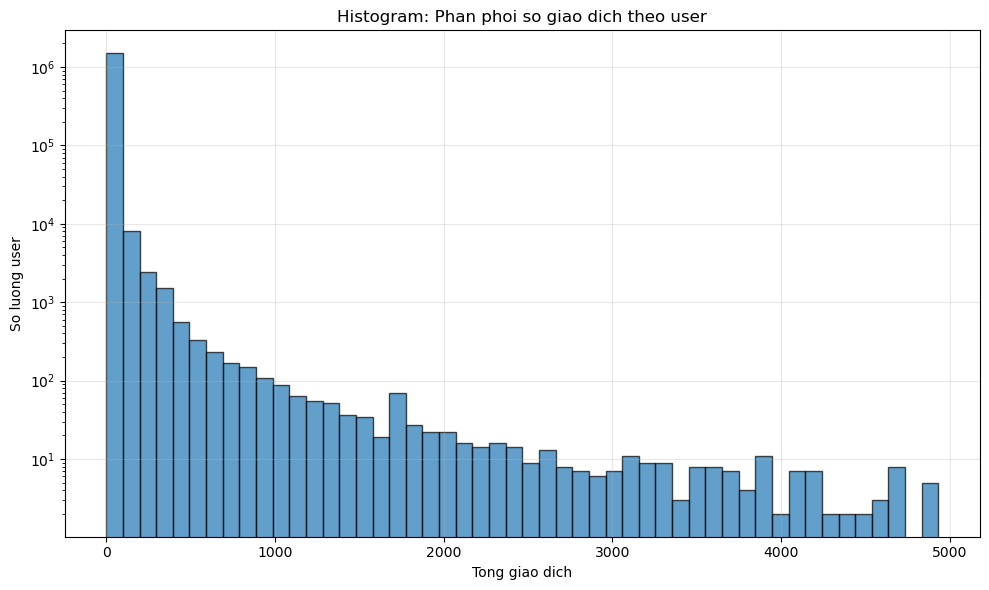

In [ ]:
# Ve histogram phan phoi so giao dich theo user

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_pandas = df_user_token_count.toPandas().sort_values("total_tx_count", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_pandas["total_tx_count"], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel("Tong giao dich")
ax.set_ylabel("So luong user")
ax.set_title("Histogram: Phan phoi so giao dich theo user")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


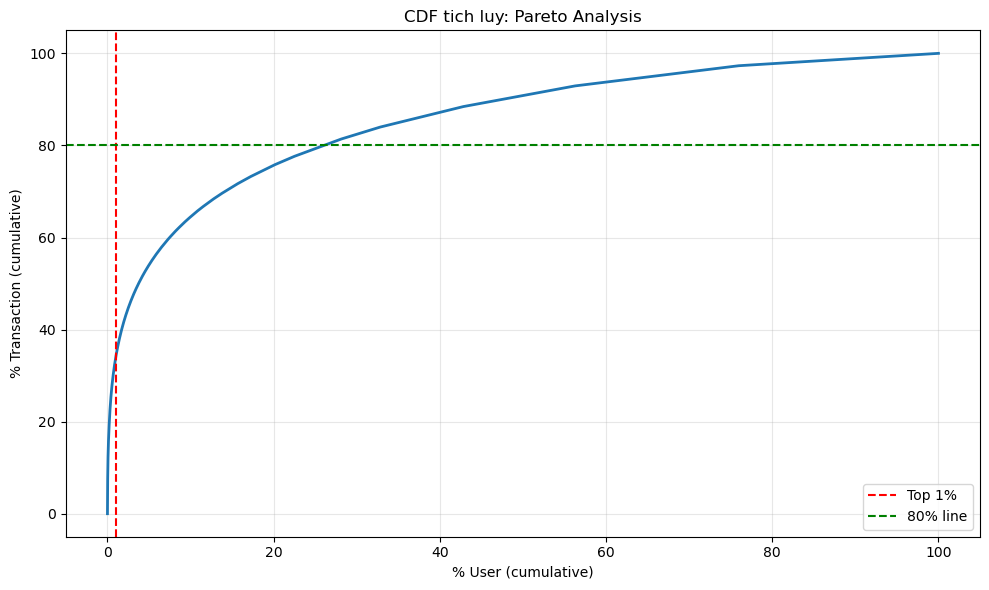

In [ ]:
# CDF tich luy

sorted_tx = np.sort(df_pandas["total_tx_count"].values)[::-1]
cum_sum = np.cumsum(sorted_tx)
cum_pct = cum_sum / cum_sum[-1]
user_pct = np.arange(1, len(sorted_tx) + 1) / len(sorted_tx)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(user_pct * 100, cum_pct * 100, linewidth=2)
ax.axvline(1, color='red', linestyle='--', label='Top 1%')
ax.axhline(80, color='green', linestyle='--', label='80% line')
ax.set_xlabel("% User (cumulative)")
ax.set_ylabel("% Transaction (cumulative)")
ax.set_title("CDF tich luy: Pareto Analysis")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Nhận xét 2 biểu đồ

### 1. Histogram - Phân phối số giao dịch theo user 
- **Phân phối lệch phải rất mạnh**: Đa số user có số giao dịch thấp, chỉ một tỷ lệ nhỏ có số giao dịch rất cao (heavy users)
- **Có tính heavy-tail**: Dữ liệu không tuân theo phân phối chuẩn, đuôi dài kéo dài tới 5000 giao dịch
- **Sử dụng trục log là cần thiết**: Vì chênh lệch tần suất giữa nhóm phổ biến (~200K user) và nhóm cực trị (< 10 user) quá lớn, không thể hiện rõ trên trục tuyến tính

### 2. CDF tích lũy 
- **Tập trung cao**: Đường CDF tăng rất nhanh ở đoạn đầu → một tỷ lệ rất nhỏ user đóng góp phần lớn giao dịch
- **Quy luật Pareto rõ ràng**: 
  - Top 1% user (đỏ) đã đạt ~38% tổng giao dịch
  - Cần khoảng 15-20% user để đạt 80% tổng giao dịch (xanh)
- **Phân hóa cực cao**: Chênh lệch lớn giữa heavy users vs light users


## Lập ma trận User x Token


In [11]:
from pyspark.sql import Window

In [14]:
# Tạo ma trận User x Token (dùng balance làm giá trị)
# mapping user_address -> user_id
df_user_map = (
    df_real_user_portfolios
    .select("user_address")
    .distinct()
    .orderBy("user_address")
    .withColumn("user_id", F.row_number().over(Window.orderBy("user_address")))
)

# Tạo mapping token_address -> token_id
df_token_map = (
    df_real_user_portfolios
    .select("token_address")
    .distinct()
    .orderBy("token_address")
    .withColumn("token_id", F.row_number().over(Window.orderBy("token_address")))
)

num_users = df_user_map.count()
num_tokens = df_token_map.count()

# Join với dữ liệu gốc để lấy user_id và token_id
df_indexed = (
    df_real_user_portfolios
    .join(df_user_map, on="user_address", how="left")
    .join(df_token_map, on="token_address", how="left")
    .select("user_id", "token_id", "balance", "tx_count")
)

num_entries = df_indexed.count()  # Số phần tử khác 0

print(f"Số user: {num_users}")
print(f"Số token: {num_tokens}")
print(f"Số phần tử (entries): {num_entries}")

# Tính ma trận kích thước
total_elements = num_users * num_tokens
sparsity = (1 - num_entries / total_elements) * 100

print(f"\nKích thước ma trận: {num_users} x {num_tokens} = {total_elements:,} phần tử")
print(f"Độ thưa (Sparsity): {sparsity:.4f}%")


Số user: 1507632
Số token: 1035
Số phần tử (entries): 1528520

Kích thước ma trận: 1507632 x 1035 = 1,560,399,120 phần tử
Độ thưa (Sparsity): 99.9020%


## Thử lọc ma trân theo điều kiện: user activity + token popularity muc tiêu giảm sparsity và vẫn giữ đủ dữ liệu huấn luyện

In [23]:
user_thresholds = [10, 20, 50]
token_thresholds = [10, 20, 50]

user_tx = (
    df_real_user_portfolios
    .groupBy("user_address")
    .agg(F.sum("tx_count").alias("total_tx"))
)

token_holders = (
    df_real_user_portfolios
    .groupBy("token_address")
    .agg(F.countDistinct("user_address").alias("num_holders"))
)

df_scored = (
    df_real_user_portfolios
    .join(user_tx, on="user_address", how="left")
    .join(token_holders, on="token_address", how="left")
    .select("user_address", "token_address", "total_tx", "num_holders")
    .cache()
)
_ = df_scored.count()

results = []

for min_tx in user_thresholds:
    for min_holders in token_thresholds:
        df_combined = df_scored.filter(
            (F.col("total_tx") >= min_tx) & (F.col("num_holders") >= min_holders)
        )

        metrics = df_combined.agg(
            F.count("*").alias("entries"),
            F.countDistinct("user_address").alias("users"),
            F.countDistinct("token_address").alias("tokens")
        ).first()

        n_entries = int(metrics["entries"])
        n_users = int(metrics["users"])
        n_tokens = int(metrics["tokens"])

        total_cells = n_users * n_tokens
        sparsity_combined = (1 - n_entries / total_cells) * 100 if total_cells > 0 else 100.0

        results.append({
            "min_tx": min_tx,
            "min_holders": min_holders,
            "users": n_users,
            "tokens": n_tokens,
            "entries": n_entries,
            "sparsity_pct": round(sparsity_combined, 4)
        })

results_sorted = sorted(results, key=lambda x: x["sparsity_pct"])
print("Bang so sanh loc ket hop (sap xep theo sparsity tang dan):")
for r in results_sorted:
    print(
        f"- min_tx>={r['min_tx']:2d}, min_holders>={r['min_holders']:2d} "
        f"| users={r['users']:,}, tokens={r['tokens']:,}, entries={r['entries']:,} "
        f"| sparsity={r['sparsity_pct']:.4f}%"
    )




Bang so sanh loc ket hop (sap xep theo sparsity tang dan):
- min_tx>=50, min_holders>=50 | users=33,931, tokens=106, entries=39,147 | sparsity=98.9116%
- min_tx>=20, min_holders>=50 | users=104,658, tokens=106, entries=112,297 | sparsity=98.9877%
- min_tx>=10, min_holders>=50 | users=232,502, tokens=106, entries=242,956 | sparsity=99.0142%
- min_tx>=50, min_holders>=20 | users=33,942, tokens=156, entries=39,466 | sparsity=99.2546%
- min_tx>=20, min_holders>=20 | users=104,685, tokens=157, entries=112,697 | sparsity=99.3143%
- min_tx>=10, min_holders>=20 | users=232,566, tokens=158, entries=243,483 | sparsity=99.3374%
- min_tx>=50, min_holders>=10 | users=33,945, tokens=197, entries=39,593 | sparsity=99.4079%
- min_tx>=20, min_holders>=10 | users=104,697, tokens=202, entries=112,872 | sparsity=99.4663%
- min_tx>=10, min_holders>=10 | users=232,589, tokens=205, entries=243,705 | sparsity=99.4889%


In [25]:
# Lọc cố định theo cấu hình bạn muốn: min_tx >= 10, min_holders >= 50

df_filtered_10_50 = df_scored.filter(
    (F.col("total_tx") >= 10) & (F.col("num_holders") >= 50)
)

metrics_10_50 = df_filtered_10_50.agg(
    F.count("*").alias("entries"),
    F.countDistinct("user_address").alias("users"),
    F.countDistinct("token_address").alias("tokens")
).first()

filtered_users = int(metrics_10_50["users"])
filtered_tokens = int(metrics_10_50["tokens"])
filtered_entries = int(metrics_10_50["entries"])
filtered_sparsity = (1 - filtered_entries / (filtered_users * filtered_tokens)) * 100 if filtered_users * filtered_tokens > 0 else 100.0

print("Filter config: min_tx >= 10, min_holders >= 50")
print(f"Users: {filtered_users:,}")
print(f"Tokens: {filtered_tokens:,}")
print(f"Entries: {filtered_entries:,}")
print(f"Sparsity: {filtered_sparsity:.4f}%")

# Lưu dataset đã lọc để dùng cho recommendation
output_dir_filtered_10_50 = "/home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token"
df_filtered_10_50.write.mode("overwrite").parquet(output_dir_filtered_10_50)
print(f"Saved filtered dataset to: {output_dir_filtered_10_50}")

Filter config: min_tx >= 10, min_holders >= 50
Users: 232,502
Tokens: 106
Entries: 242,956
Sparsity: 99.0142%
Saved filtered dataset to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token


In [26]:
df_filtered_10_50.show(10)

+--------------------+--------------------+--------+-----------+
|        user_address|       token_address|total_tx|num_holders|
+--------------------+--------------------+--------+-----------+
|0x000b802295208e8...|0xdac17f958d2ee52...|      17|    1404064|
|0x000b802295208e8...|0x0cc4f8735dae4b1...|      17|        475|
|0x0029b1addd746c1...|0xdac17f958d2ee52...|      10|    1404064|
|0x0084f81dde0939c...|0xdac17f958d2ee52...|      11|    1404064|
|0x009898e6bc87557...|0xdac17f958d2ee52...|      11|    1404064|
|0x00d03f805fa52ac...|0xc02aaa39b223fe8...|      11|      33797|
|0x012a3d54d28152a...|0xdac17f958d2ee52...|      36|    1404064|
|0x014c2b86e69dd18...|0xdac17f958d2ee52...|      11|    1404064|
|0x01793bf37aae98b...|0xdac17f958d2ee52...|      17|    1404064|
|0x0179e365cab0d43...|0xdac17f958d2ee52...|      17|    1404064|
+--------------------+--------------------+--------+-----------+
only showing top 10 rows


### Tạo map user_id và token_id 

In [12]:
base = "/home/khanhdo/Documents/project/bigdata_mining/data_processed"

# 1) Load processed token transfers (for building user map)
transfer_candidates = [
    f"{base}/processed_token_transfers",
    f"{base}/processed_token_transfers.parquet"
 ]

df_processed_transfers = None
loaded_transfer_path = None
for p in transfer_candidates:
    try:
        df_processed_transfers = spark.read.parquet(p)
        loaded_transfer_path = p
        break
    except Exception:
        pass

if df_processed_transfers is None:
    raise FileNotFoundError("Khong tim thay processed_token_transfers trong data_processed")

# 2) Build one user map only: user_address -> user_id
df_all_users = (
    df_processed_transfers
    .select(F.lower(F.col("from_address")).alias("user_address"))
    .union(
        df_processed_transfers.select(F.lower(F.col("to_address")).alias("user_address"))
    )
    .filter(F.col("user_address").isNotNull())
    .filter(F.col("user_address") != "")
    .dropDuplicates(["user_address"])
)

df_user_map = (
    df_all_users
    .orderBy("user_address")
    .withColumn("user_id", F.row_number().over(Window.orderBy("user_address")))
)

# 3) Build token map from processed_token.csv (fallback to processed_tokens.csv)
token_csv_candidates = [
    f"{base}/processed_token.csv",
    f"{base}/processed_tokens.csv"
 ]

df_tokens_csv = None
loaded_token_csv_path = None
for csv_path in token_csv_candidates:
    try:
        df_tokens_csv = (
            spark.read
            .option("header", True)
            .option("multiLine", True)
            .option("quote", '"')
            .option("escape", '"')
            .csv(csv_path)
        )
        loaded_token_csv_path = csv_path
        break
    except Exception:
        pass

if df_tokens_csv is None:
    raise FileNotFoundError("Khong tim thay processed_token.csv hoac processed_tokens.csv trong data_processed")

df_token_map = (
    df_tokens_csv
    .select(F.lower(F.trim(F.col("address"))).alias("token_address"))
    .filter(F.col("token_address").rlike(r"^0x[0-9a-f]{40}$"))
    .dropDuplicates(["token_address"])
    .orderBy("token_address")
    .withColumn("token_id", F.row_number().over(Window.orderBy("token_address")))
)

# 4) Save maps
map_dir = f"{base}/map_filtered_user_token"
df_user_map.write.mode("overwrite").parquet(f"{map_dir}/users")
df_token_map.write.mode("overwrite").parquet(f"{map_dir}/tokens")

# 5) Index ONLY rows from filtered_user_token dataset
filtered_candidates = [
    f"{base}/filtered_user_token",
    f"{base}/filtered_tx10_holders50"
 ]

df_filtered_user_token = None
loaded_filtered_path = None
for fp in filtered_candidates:
    try:
        df_filtered_user_token = spark.read.parquet(fp)
        loaded_filtered_path = fp
        break
    except Exception:
        pass

if df_filtered_user_token is None:
    raise FileNotFoundError("Khong tim thay filtered_user_token hoac filtered_tx10_holders50 trong data_processed")

df_filtered_index_source = (
    df_filtered_user_token
    .select(
        F.lower(F.col("user_address")).alias("user_address"),
        F.lower(F.col("token_address")).alias("token_address"),
        *[c for c in df_filtered_user_token.columns if c not in ["user_address", "token_address"]]
    )
    .filter(F.col("user_address").isNotNull())
    .filter(F.col("user_address") != "")
    .filter(F.col("token_address").isNotNull())
    .filter(F.col("token_address") != "")
)

extra_cols = [c for c in df_filtered_index_source.columns if c not in ["user_address", "token_address"]]

# Keep only post-index values (ID columns + remaining feature columns), sorted by user_id
df_indexed_user_token = (
    df_filtered_index_source
    .join(df_user_map, on="user_address", how="inner")
    .join(df_token_map, on="token_address", how="inner")
    .select("user_id", "token_id", *extra_cols)
    .orderBy("user_id", "token_id")
)

indexed_dir = f"{base}/indexed_user_token"
df_indexed_user_token.write.mode("overwrite").parquet(indexed_dir)

print(f"Loaded transfers from: {loaded_transfer_path}")
print(f"Loaded token CSV from: {loaded_token_csv_path}")
print(f"Loaded filtered dataset from: {loaded_filtered_path}")
print(f"User map rows: {df_user_map.count():,}")
print(f"Token map rows: {df_token_map.count():,}")
print(f"Indexed rows (from filtered dataset only): {df_indexed_user_token.count():,}")
print("Indexed columns:", df_indexed_user_token.columns)
print(f"Saved user map to: {map_dir}/users")
print(f"Saved token map to: {map_dir}/tokens")
print(f"Saved indexed dataset to: {indexed_dir}")

26/04/20 23:40:05 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_token.csv.
java.io.FileNotFoundException: File /home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_token.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.FileStreamSink$.hasMetadata(FileStreamSink.scala:56)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:381)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysi

Loaded transfers from: /home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_token_transfers
Loaded token CSV from: /home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_tokens.csv
Loaded filtered dataset from: /home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token


User map rows: 4,836,609
Token map rows: 173,832


Indexed rows (from filtered dataset only): 242,956
Indexed columns: ['user_id', 'token_id', 'total_tx', 'num_holders']
Saved user map to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/users
Saved token map to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/tokens
Saved indexed dataset to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/indexed_user_token


## User_token sau khi index

In [13]:
df_user_map = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/users")
df_token_map = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/tokens")

print("User map sample:")
print(df_user_map.count())
df_user_map.show(5, truncate=False)
print("Token map sample:")
print(df_token_map.count())
df_token_map.show(5, truncate=False)

User map sample:
4836609
+------------------------------------------+-------+
|user_address                              |user_id|
+------------------------------------------+-------+
|0x0000000000000000000000000000000000000000|1      |
|0x0000000000000000000000000000000000000001|2      |
|0x0000000000000000000000000000000000000002|3      |
|0x0000000000000000000000000000000000000018|4      |
|0x0000000000000000000000000000000000000020|5      |
+------------------------------------------+-------+
only showing top 5 rows
Token map sample:
173832
+------------------------------------------+--------+
|token_address                             |token_id|
+------------------------------------------+--------+
|0x0000000000b3f879cb30fe243b4dfee438691c04|1       |
|0x000000002647e16d9bab9e46604d75591d289277|2       |
|0x00000000e86b5156e8fd624255bf7a6d722a8f1f|3       |
|0x00000007b0390fc9ca72f534366f5c02d5af5334|4       |
|0x0000000a9e27410f13dd4818488bf1e706c9a2fe|5       |
+----------------

In [14]:
df_indexed_user_token = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/indexed_user_token")
df_indexed_user_token = df_indexed_user_token.orderBy("user_id", "token_id")

df_indexed_user_token.show(20, truncate=False)
print("Indexed rows:", df_indexed_user_token.count())
print("Indexed columns:", df_indexed_user_token.columns)

+-------+--------+--------+-----------+
|user_id|token_id|total_tx|num_holders|
+-------+--------+--------+-----------+
|6      |15798   |33      |541        |
|8      |15798   |11      |541        |
|9      |15798   |21      |541        |
|10     |15798   |33      |541        |
|20     |15798   |164     |541        |
|25     |15798   |82      |541        |
|29     |15798   |21      |541        |
|33     |15798   |11      |541        |
|36     |15798   |19      |541        |
|39     |15798   |19      |541        |
|43     |15798   |50      |541        |
|51     |15798   |348     |541        |
|51     |43757   |348     |374        |
|51     |53043   |348     |211        |
|51     |55204   |348     |27330      |
|51     |59513   |348     |94         |
|51     |79133   |348     |171        |
|51     |95567   |348     |57         |
|51     |109069  |348     |2083       |
|51     |125192  |348     |1888       |
+-------+--------+--------+-----------+
only showing top 20 rows
Indexed rows: 2

In [15]:
base = "/home/khanhdo/Documents/project/bigdata_mining/data_processed"

# Load source and mapping tables
df_processed_transfers = spark.read.parquet(f"{base}/processed_token_transfers")
df_user_map = spark.read.parquet(f"{base}/map_filtered_user_token/users")
df_token_map = spark.read.parquet(f"{base}/map_filtered_user_token/tokens")

# Normalize keys before mapping
df_src = (
    df_processed_transfers
    .select(
        F.lower(F.col("from_address")).alias("from_address"),
        F.lower(F.col("to_address")).alias("to_address"),
        F.lower(F.col("token_address")).alias("token_address"),
        F.col("adjusted_value")
    )
)

df_from_map = df_user_map.select(
    F.lower(F.col("user_address")).alias("from_address"),
    F.col("user_id").alias("from_user_id")
)

df_to_map = df_user_map.select(
    F.lower(F.col("user_address")).alias("to_address"),
    F.col("user_id").alias("to_user_id")
)

df_tok_map = df_token_map.select(
    F.lower(F.col("token_address")).alias("token_address"),
    F.col("token_id")
)

# Map IDs and keep only mapped columns
df_processed_transfers_mapped = (
    df_src
    .join(df_from_map, on="from_address", how="left")
    .join(df_to_map, on="to_address", how="left")
    .join(df_tok_map, on="token_address", how="left")
    .select(
        "from_user_id",
        "to_user_id",
        "token_id",
        "adjusted_value"
    )
)

df_processed_transfers_mapped.show(20, truncate=False)
print("Rows:", df_processed_transfers_mapped.count())
print(
    "Null mapped IDs:",
    df_processed_transfers_mapped.filter(
        F.col("from_user_id").isNull() | F.col("to_user_id").isNull() | F.col("token_id").isNull()
    ).count()
)

+------------+----------+--------+----------------+
|from_user_id|to_user_id|token_id|adjusted_value  |
+------------+----------+--------+----------------+
|267274      |784248    |148306  |1310.17         |
|438615      |795481    |148306  |1.0E-4          |
|237         |961441    |148306  |54.11641        |
|237         |961441    |148306  |54.914414       |
|516499      |1559989   |148306  |4056.29804      |
|3598243     |1597160   |148306  |1728.328604     |
|618608      |1983152   |130121  |1.0E-17         |
|1174672     |2897850   |148306  |74.53           |
|1602041     |3132581   |148306  |47.080533       |
|98208       |3574835   |148306  |140.0           |
|2677365     |3598004   |148306  |2.0E-4          |
|237         |4042449   |148306  |238.987547      |
|618608      |421       |130121  |1.0E-17         |
|618608      |421       |130121  |1.0E-17         |
|1784209     |116493    |148306  |35.54           |
|1187935     |133855    |148306  |0.005           |
|1344519    

Rows: 36343432


Null mapped IDs: 0


In [ ]:
df_processed_transfers_mapped.write.mode("overwrite").parquet(f"{base}/indexed_processed_transfers")


In [20]:
ddfsafd = spark.read.parquet(f"{base}/real_user_portfolios")
ddfsafd.show(5, truncate=False)
print(ddfsafd.count())

+------------------------------------------+------------------------------------------+---------------------+--------+-------------------+-----------+
|user_address                              |token_address                             |balance              |tx_count|last_active        |is_contract|
+------------------------------------------+------------------------------------------+---------------------+--------+-------------------+-----------+
|0x0002f8920bcb84e9cf9dc45200a1039c1e6f44ee|0xdac17f958d2ee523a2206206994597c13d831ec7|2.842170943040401E-14|6       |2026-03-09 09:16:11|false      |
|0x00047fdfc28133e60cf92e39cb62a219f9ad3044|0x0cc4f8735dae4b1ab7682cb05aeb19115e693e98|2.0E-18              |1       |2026-03-10 03:10:11|false      |
|0x000b802295208e8d523160e97905b04f248f6d51|0xdac17f958d2ee523a2206206994597c13d831ec7|77105.117673         |16      |2026-03-21 10:18:35|false      |
|0x000b802295208e8d523160e97905b04f248f6d51|0x0cc4f8735dae4b1ab7682cb05aeb19115e693e98|3.0E-18

In [5]:
d1 = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token")
d1.show(5, truncate=False)
print(d1.count())

+------------------------------------------+------------------------------------------+--------+-----------+
|user_address                              |token_address                             |total_tx|num_holders|
+------------------------------------------+------------------------------------------+--------+-----------+
|0x003a341e68c7f1af3a0ae771e6f11c50765a425a|0xdac17f958d2ee523a2206206994597c13d831ec7|17      |1404064    |
|0x004daae2621017da004fbf15135f9ecb6d3b900c|0xdac17f958d2ee523a2206206994597c13d831ec7|97      |1404064    |
|0x00613966b9ed245cfece04b523bd89d0d0423731|0xdac17f958d2ee523a2206206994597c13d831ec7|29      |1404064    |
|0x00a9206b41d964f85004e1cc9cf4a1b019faffc5|0xdac17f958d2ee523a2206206994597c13d831ec7|29      |1404064    |
|0x00c32177b01915fbf466562727ece4d88aa2df3b|0xdac17f958d2ee523a2206206994597c13d831ec7|82      |1404064    |
+------------------------------------------+------------------------------------------+--------+-----------+
only showing top 5 

In [6]:
df = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/real_user_portfolios")
df.show(5, truncate=False)
print(df.count())

+------------------------------------------+------------------------------------------+---------------------+--------+-------------------+-----------+
|user_address                              |token_address                             |balance              |tx_count|last_active        |is_contract|
+------------------------------------------+------------------------------------------+---------------------+--------+-------------------+-----------+
|0x0002f8920bcb84e9cf9dc45200a1039c1e6f44ee|0xdac17f958d2ee523a2206206994597c13d831ec7|2.842170943040401E-14|6       |2026-03-09 09:16:11|false      |
|0x00047fdfc28133e60cf92e39cb62a219f9ad3044|0x0cc4f8735dae4b1ab7682cb05aeb19115e693e98|2.0E-18              |1       |2026-03-10 03:10:11|false      |
|0x000b802295208e8d523160e97905b04f248f6d51|0xdac17f958d2ee523a2206206994597c13d831ec7|77105.117673         |16      |2026-03-21 10:18:35|false      |
|0x000b802295208e8d523160e97905b04f248f6d51|0x0cc4f8735dae4b1ab7682cb05aeb19115e693e98|3.0E-18